In [25]:
pip install pandas numpy scikit-learn matplotlib seaborn plotly streamlit

Note: you may need to restart the kernel to use updated packages.


In [16]:
import os
os.environ["OMP_NUM_THREADS"] = "5"

In [7]:
import pandas as pd
df = pd.read_csv("BigData/transactions_data.csv")

print(df.shape)     # number of rows & columns
print(df.columns)   # column names

df.info()
df.describe()
df.head()

(7779222, 12)
Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7779222 entries, 0 to 7779221
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          object 
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             float64
 11  errors          object 
dtypes: float64(2), int64(4), object(6)
memory usage: 712.2+ MB


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499.0,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311.0,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829.0,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829.0,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813.0,NaN


In [9]:
import os
os.chdir("C:/Users/User/BigData")

In [10]:
df['amount'] = df['amount'].replace('[\$,]', '', regex=True).astype(float)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7779222 entries, 0 to 7779221
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          float64
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             float64
 11  errors          object 
dtypes: float64(3), int64(4), object(5)
memory usage: 712.2+ MB


In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
df.isnull().sum()

id                      0
date                    0
client_id               0
card_id                 0
amount                  0
use_chip                0
merchant_id             0
merchant_city           0
merchant_state     888962
zip                939319
mcc                     1
errors            7655880
dtype: int64

In [14]:
df = df.drop(columns=['errors'])

In [15]:
df['merchant_state'] = df['merchant_state'].fillna('Unknown')

In [16]:
df = df.drop(columns=['zip'])

In [17]:
# Drop useless columns
df = df.drop(columns=['errors', 'zip'])

# Fill categorical missing values
df['merchant_state'] = df['merchant_state'].fillna('Unknown')

KeyError: "['errors', 'zip'] not found in axis"

In [18]:
print(df.columns)

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'mcc'],
      dtype='object')


In [19]:
df = df.drop(columns=['errors', 'zip'], errors='ignore')

In [20]:
print(df.columns)

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'mcc'],
      dtype='object')


In [21]:
df.isnull().sum()

id                0
date              0
client_id         0
card_id           0
amount            0
use_chip          0
merchant_id       0
merchant_city     0
merchant_state    0
mcc               1
dtype: int64

In [22]:
df['merchant_state'] = df['merchant_state'].fillna('Unknown')

In [23]:
df_sample = df.sample(n=100000, random_state=42)

In [24]:
df_sample.head()
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 1991328 to 4840487
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              100000 non-null  int64         
 1   date            100000 non-null  datetime64[ns]
 2   client_id       100000 non-null  int64         
 3   card_id         100000 non-null  int64         
 4   amount          100000 non-null  float64       
 5   use_chip        100000 non-null  object        
 6   merchant_id     100000 non-null  int64         
 7   merchant_city   100000 non-null  object        
 8   merchant_state  100000 non-null  object        
 9   mcc             100000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 8.4+ MB


In [1]:
df_features = df.groupby('client_id').agg({
    'amount': ['sum', 'mean', 'count'],
    'date': ['max']
}).reset_index()

NameError: name 'df' is not defined

In [2]:
import pandas as pd

# Load dataset (use your correct path)
df = pd.read_csv("BigData/transactions_data.csv")

# Fix amount
df['amount'] = df['amount'].replace('[\$,]', '', regex=True).astype(float)

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Drop columns safely
df = df.drop(columns=['errors', 'zip'], errors='ignore')

# Fill missing values
df['merchant_state'] = df['merchant_state'].fillna('Unknown')

# Sample data (IMPORTANT)
df = df.sample(n=100000, random_state=42)

In [3]:
df_features = df.groupby('client_id').agg({
    'amount': ['sum', 'mean', 'count'],
    'date': ['max']
}).reset_index()

df_features.columns = ['client_id', 'total_spent', 'avg_spent', 'transaction_count', 'last_transaction']

latest_date = df['date'].max()
df_features['recency'] = (latest_date - df_features['last_transaction']).dt.days

df_features = df_features.drop(columns=['last_transaction'])

df_features.head()

,client_id,total_spent,avg_spent,transaction_count,recency
0,0,3795.65,41.257065,92,49
1,1,3732.36,38.085306,98,8
2,2,2604.60,27.131250,96,17
3,3,2271.11,44.531569,51,26
4,4,5545.02,49.070973,113,70


In [4]:
df_features.describe()

,client_id,total_spent,avg_spent,transaction_count,recency
count,1209.000000,1209.000000,1209.000000,1209.000000,1209.000000
mean,1004.466501,3567.788337,44.066906,82.712986,37.103391
std,582.568606,2386.544162,20.350547,43.997041,98.555494
min,0.000000,28.850000,4.598333,2.000000,0.000000
25%,494.000000,1956.020000,29.907719,54.000000,7.000000
50%,1020.000000,2979.790000,40.500265,74.000000,19.000000
75%,1513.000000,4657.310000,55.568351,102.000000,40.000000
max,1998.000000,18603.180000,137.714732,397.000000,2006.000000


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df_features.drop(columns=['client_id'])
X_scaled = scaler.fit_transform(X)

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df_features['cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [8]:
df_features.head()

,client_id,total_spent,avg_spent,transaction_count,recency,cluster
0,0,3795.65,41.257065,92,49,0
1,1,3732.36,38.085306,98,8,0
2,2,2604.60,27.131250,96,17,0
3,3,2271.11,44.531569,51,26,0
4,4,5545.02,49.070973,113,70,2


In [9]:
df_features.groupby('cluster').mean()

,client_id,total_spent,avg_spent,transaction_count,recency
cluster,,,,,
0,968.713669,2175.539424,32.702002,68.522302,34.164029
1,1028.074675,4680.331104,68.962092,69.282468,36.233766
2,1078.030000,6761.187450,44.935636,154.495000,12.920000
3,1481.833333,1279.455000,53.591074,23.166667,1228.333333


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

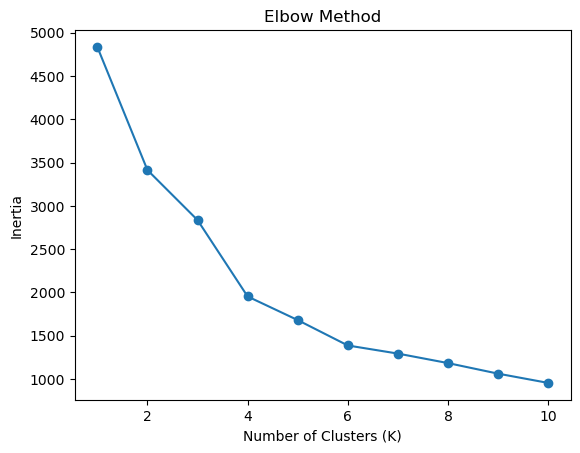

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_features['cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [13]:
OMP_NUM_THREADS=5

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_features['cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

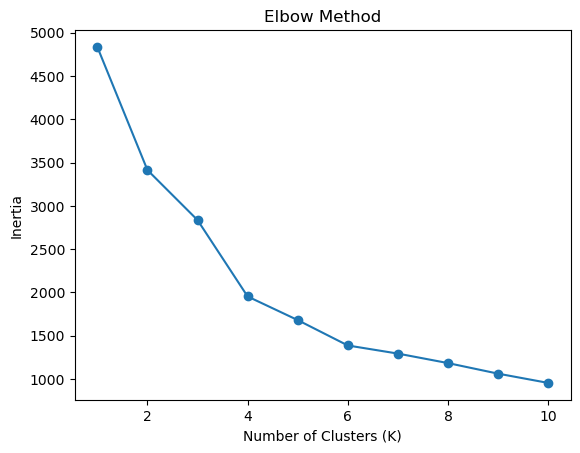

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_features['cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [19]:
df_features.groupby('cluster').mean()

,client_id,total_spent,avg_spent,transaction_count,recency
cluster,,,,,
0,968.713669,2175.539424,32.702002,68.522302,34.164029
1,1028.074675,4680.331104,68.962092,69.282468,36.233766
2,1078.030000,6761.187450,44.935636,154.495000,12.920000
3,1481.833333,1279.455000,53.591074,23.166667,1228.333333


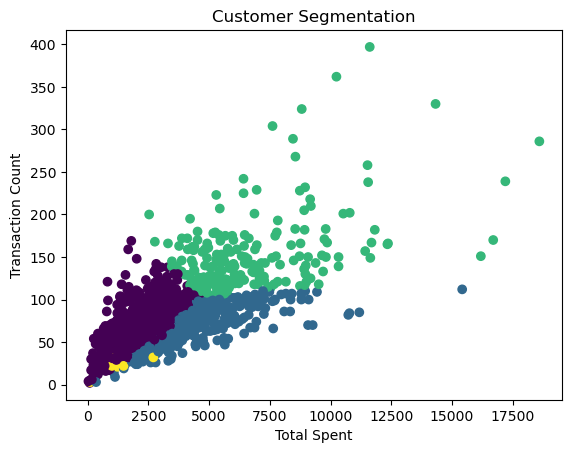

In [20]:
import matplotlib.pyplot as plt

plt.scatter(df_features['total_spent'], df_features['transaction_count'], c=df_features['cluster'])
plt.xlabel('Total Spent')
plt.ylabel('Transaction Count')
plt.title('Customer Segmentation')
plt.show()

In [21]:
import warnings
warnings.filterwarnings("ignore")

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_features['cluster'] = kmeans.fit_predict(X_scaled)

In [23]:
df_features.groupby('cluster').mean()

,client_id,total_spent,avg_spent,transaction_count,recency
cluster,,,,,
0,968.713669,2175.539424,32.702002,68.522302,34.164029
1,1028.074675,4680.331104,68.962092,69.282468,36.233766
2,1078.030000,6761.187450,44.935636,154.495000,12.920000
3,1481.833333,1279.455000,53.591074,23.166667,1228.333333


In [24]:
df_features['target'] = (df_features['total_spent'] > df_features['total_spent'].median()).astype(int)

In [25]:
from sklearn.model_selection import train_test_split

X = df_features.drop(columns=['client_id', 'cluster', 'target'])
y = df_features['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       128
           1       1.00      1.00      1.00       114

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242



In [29]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

total_spent          0.788372
transaction_count    0.108681
avg_spent            0.099955
recency              0.002992
dtype: float64


In [30]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [33]:
df_features.to_csv("df_features.csv", index=False)

In [34]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\User
['.anaconda', '.android', '.codex', '.conda', '.continuum', '.emulator_console_auth_token', '.gitconfig', '.gradle', '.insomniac', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.node_repl_history', '.skiko', '01_data_exploration.ipynb', 'anaconda3', 'anaconda_projects', 'ansel', 'AppData', 'Application Data', 'BigData', 'Contacts', 'Cookies', 'data', 'Desktop', 'df_features.csv', 'Documents', 'Downloads', 'Favorites', 'Lab1.ipynb', 'Lab2ControlStructures.ipynb', 'Lab3.ipynb', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{e5a5a0ee-78a5-11f0-931c-b1dcecc99249}.TM.blf', 'NTUSER.DAT{e5a5a0ee-78a5-11f0-931c-b1dcecc99249}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{e5a5a0ee-78a5-11f0-931c-b1dcecc99249}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'PyCharmMiscProject', 'Rave.dat', 'Recent', 'Saved Games', 'Se

In [1]:
df_features.groupby('cluster').mean()

NameError: name 'df_features' is not defined

In [2]:
import pandas as pd

df_features = pd.read_csv("BigData/df_features.csv")

In [3]:
df_features.groupby('cluster').mean()

,client_id,total_spent,avg_spent,transaction_count,recency,target
cluster,,,,,,
0,968.713669,2175.539424,32.702002,68.522302,34.164029,0.215827
1,1028.074675,4680.331104,68.962092,69.282468,36.233766,0.831169
2,1078.030000,6761.187450,44.935636,154.495000,12.920000,0.990000
3,1481.833333,1279.455000,53.591074,23.166667,1228.333333,0.000000


In [1]:
print(df_features.head())

NameError: name 'df_features' is not defined

In [2]:
import pandas as pd

df_features = pd.read_csv("df_features.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'df_features.csv'

In [3]:
import pandas as pd

df_features = pd.read_csv("df_features.csv")

print(df_features.head())

FileNotFoundError: [Errno 2] No such file or directory: 'df_features.csv'

In [4]:
import pandas as pd

df_features = pd.read_csv(r"C:\Users\User\BigData\df_features.csv")

print(df_features.head())

   client_id  total_spent  avg_spent  transaction_count  recency  cluster  \
0          0      3795.65  41.257065                 92       49        0   
1          1      3732.36  38.085306                 98        8        0   
2          2      2604.60  27.131250                 96       17        0   
3          3      2271.11  44.531569                 51       26        0   
4          4      5545.02  49.070973                113       70        2   

   target  
0       1  
1       1  
2       0  
3       0  
4       1  


                   total_spent  avg_spent  transaction_count   recency
total_spent           1.000000   0.565297           0.698690 -0.155461
avg_spent             0.565297   1.000000          -0.086201  0.049927
transaction_count     0.698690  -0.086201           1.000000 -0.218812
recency              -0.155461   0.049927          -0.218812  1.000000


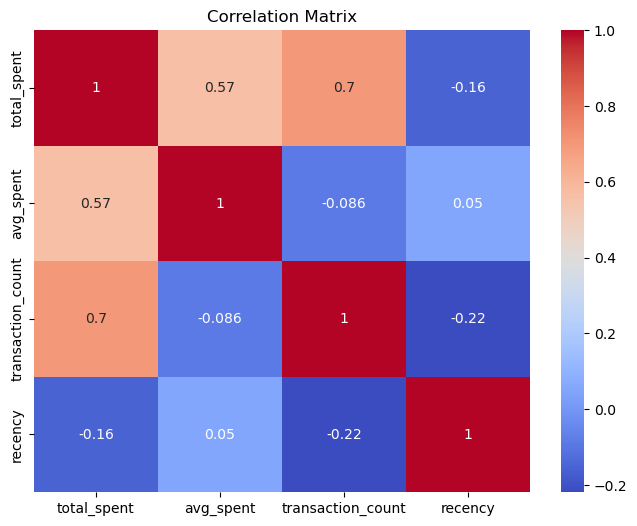

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df_features[['total_spent', 'avg_spent',
                           'transaction_count', 'recency']].corr()

print(correlation)

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X = df_features.drop(columns=['client_id', 'cluster', 'target'])
y = df_features['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 1.0


In [8]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 1.0


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 1.0


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


NameError: name 'y_pred' is not defined

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train model
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred))

Random Forest Accuracy: 1.0


In [14]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


In [15]:
df_features.groupby('cluster').mean()

,client_id,total_spent,avg_spent,transaction_count,recency,target
cluster,,,,,,
0,968.713669,2175.539424,32.702002,68.522302,34.164029,0.215827
1,1028.074675,4680.331104,68.962092,69.282468,36.233766,0.831169
2,1078.030000,6761.187450,44.935636,154.495000,12.920000,0.990000
3,1481.833333,1279.455000,53.591074,23.166667,1228.333333,0.000000


In [17]:
X = df_features.drop(columns=[
    'client_id',
    'cluster',
    'target',
    'total_spent'
])

y = df_features['target']

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9008264462809917


In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9462809917355371


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred))

Random Forest Accuracy: 0.9752066115702479


In [1]:
df_features.groupby('cluster').mean()

NameError: name 'df_features' is not defined

In [2]:
import pandas as pd

df_features = pd.read_csv(
    r"C:\Users\User\BigData\df_features.csv"
)

print(df_features.head())


   client_id  total_spent  avg_spent  transaction_count  recency  cluster  \
0          0      3795.65  41.257065                 92       49        0   
1          1      3732.36  38.085306                 98        8        0   
2          2      2604.60  27.131250                 96       17        0   
3          3      2271.11  44.531569                 51       26        0   
4          4      5545.02  49.070973                113       70        2   

   target  
0       1  
1       1  
2       0  
3       0  
4       1  


In [3]:
df_features.groupby('cluster').mean()

,client_id,total_spent,avg_spent,transaction_count,recency,target
cluster,,,,,,
0,968.713669,2175.539424,32.702002,68.522302,34.164029,0.215827
1,1028.074675,4680.331104,68.962092,69.282468,36.233766,0.831169
2,1078.030000,6761.187450,44.935636,154.495000,12.920000,0.990000
3,1481.833333,1279.455000,53.591074,23.166667,1228.333333,0.000000


In [4]:
df_features.to_csv(
    r"C:\Users\User\BigData\df_features.csv",
    index=False
)

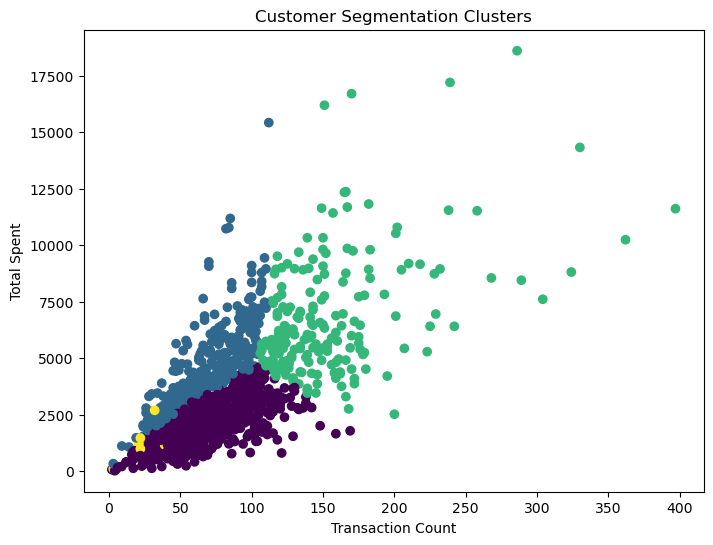

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_features['transaction_count'],
    df_features['total_spent'],
    c=df_features['cluster']
)

plt.xlabel("Transaction Count")
plt.ylabel("Total Spent")
plt.title("Customer Segmentation Clusters")

plt.show()

In [6]:
importance = rf_model.feature_importances_

features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

print(feature_importance.sort_values(
    by='Importance',
    ascending=False
))

NameError: name 'rf_model' is not defined

In [7]:
import pandas as pd

df_features = pd.read_csv(
    r"C:\Users\User\BigData\df_features.csv"
)

In [8]:
X = df_features.drop(columns=[
    'client_id',
    'cluster',
    'target',
    'total_spent'
])

y = df_features['target']

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
importance = rf_model.feature_importances_

features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

print(
    feature_importance.sort_values(
        by='Importance',
        ascending=False
    )
)


             Feature  Importance
1  transaction_count    0.475678
0          avg_spent    0.431315
2            recency    0.093008


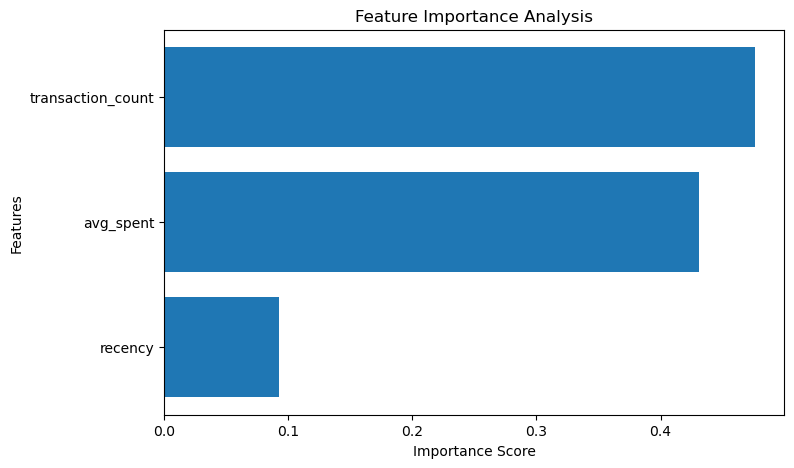

In [14]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance Analysis")

plt.show()

In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# 2. Load and Prepare Data

df = pd.read_csv("df_features.csv")

if "target" not in df.columns:
    median_spending = df["total_spent"].median()
    df["target"] = (df["total_spent"] > median_spending).astype(int)

df.head()


,client_id,total_spent,avg_spent,transaction_count,recency,cluster,target
0,0,3795.65,41.257065,92,49,0,1
1,1,3732.36,38.085306,98,8,0,1
2,2,2604.60,27.131250,96,17,0,0
3,3,2271.11,44.531569,51,26,0,0
4,4,5545.02,49.070973,113,70,2,1


In [3]:
# 3. Identify Column Types

features = ["total_spent", "avg_spent", "transaction_count", "recency"]
target = "target"

X = df[features]
y = df[target]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numeric Features:", numeric_features)
print("Target Column:", target)
print("Dataset Shape:", df.shape)

Numeric Features: ['total_spent', 'avg_spent', 'transaction_count', 'recency']
Target Column: target
Dataset Shape: (1209, 7)


In [4]:
# 4. Build Preprocessing and Random Forest Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            random_state=42
        ))
    ]
)

rf_pipeline


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [5]:
# 5. Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)


Training Set: (967, 4)
Testing Set: (242, 4)


In [6]:
# 6. Start Training Pipeline

rf_pipeline.fit(X_train, y_train)

print("Random Forest model training completed successfully.")

Random Forest model training completed successfully.


In [7]:
# 7. Model Evaluation

rf_predictions = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.9959

Confusion Matrix:
[[120   1]
 [  0 121]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       121
           1       0.99      1.00      1.00       121

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242



In [8]:
# 1. Import Libraries

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [9]:
# 2. Load and Preprocess Data

df = pd.read_csv("df_features.csv")

if "target" not in df.columns:
    median_spending = df["total_spent"].median()
    df["target"] = (df["total_spent"] > median_spending).astype(int)

features = ["total_spent", "avg_spent", "transaction_count", "recency"]

X = df[features]
y = df["target"]

df.head()

,client_id,total_spent,avg_spent,transaction_count,recency,cluster,target
0,0,3795.65,41.257065,92,49,0,1
1,1,3732.36,38.085306,98,8,0,1
2,2,2604.60,27.131250,96,17,0,0
3,3,2271.11,44.531569,51,26,0,0
4,4,5545.02,49.070973,113,70,2,1


In [10]:
# 3. Split Data into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (967, 4)
Testing Data Shape: (242, 4)


In [11]:
# 4. Define Pipeline and Hyperparameters

dt_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

param_grid = {
    "model__max_depth": [3, 5, 7, 10],
    "model__criterion": ["gini", "entropy"],
    "model__min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [3, 5, ...], 'model__min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [12]:
# 5. Model Training

grid_search.fit(X_train, y_train)

best_dt_model = grid_search.best_estimator_

print("Decision Tree training completed successfully.")
print("Best Parameters:", grid_search.best_params_)

Decision Tree training completed successfully.
Best Parameters: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_split': 2}


In [13]:
# 6. Model Evaluation

dt_predictions = best_dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", round(dt_accuracy, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy: 0.9959

Confusion Matrix:
[[120   1]
 [  0 121]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       121
           1       0.99      1.00      1.00       121

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242



In [14]:
# 7. Model Saving

joblib.dump(best_dt_model, "decision_tree_model.pkl")

print("Decision Tree model saved as decision_tree_model.pkl")

Decision Tree model saved as decision_tree_model.pkl


In [15]:
# 8. Result Saving

dt_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": dt_predictions
})

dt_results.to_csv("decision_tree_results.csv", index=False)

print("Decision Tree results saved as decision_tree_results.csv")
dt_results.head()

Decision Tree results saved as decision_tree_results.csv


,Actual,Predicted
349,0,0
381,1,1
492,1,1
1175,0,0
311,0,0


In [16]:
# 1. Import Libraries

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
# 2. Load Dataset

df = pd.read_csv("df_features.csv")

if "target" not in df.columns:
    median_spending = df["total_spent"].median()
    df["target"] = (df["total_spent"] > median_spending).astype(int)

df.head()

,client_id,total_spent,avg_spent,transaction_count,recency,cluster,target
0,0,3795.65,41.257065,92,49,0,1
1,1,3732.36,38.085306,98,8,0,1
2,2,2604.60,27.131250,96,17,0,0
3,3,2271.11,44.531569,51,26,0,0
4,4,5545.02,49.070973,113,70,2,1


In [18]:
# 3. Define Features X and Target y

features = ["total_spent", "avg_spent", "transaction_count", "recency"]

X = df[features]
y = df["target"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   total_spent  avg_spent  transaction_count  recency
0      3795.65  41.257065                 92       49
1      3732.36  38.085306                 98        8
2      2604.60  27.131250                 96       17
3      2271.11  44.531569                 51       26
4      5545.02  49.070973                113       70

Target:
0    1
1    1
2    0
3    0
4    1
Name: target, dtype: int64


In [19]:
# 4. Splitting Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (967, 4)
X_test: (242, 4)
y_train: (967,)
y_test: (242,)


In [20]:
# 5. Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")


Feature scaling completed.


In [21]:
# 6. Model Training

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model training completed successfully.")

Logistic Regression model training completed successfully.


In [22]:
# 7. Model Evaluation

lr_predictions = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_predictions))
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.9587

Confusion Matrix:
[[116   5]
 [  5 116]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       121
           1       0.96      0.96      0.96       121

    accuracy                           0.96       242
   macro avg       0.96      0.96      0.96       242
weighted avg       0.96      0.96      0.96       242



In [23]:
git add 01_data_exploration.ipynb .gitignore
git commit -m "Add Chapter 6 machine learning implementation sections"
git push origin main


SyntaxError: invalid decimal literal (3443752326.py, line 1)